In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# Data in original 2D plane
x = np.linspace(-5, 5, 50)
y = 2 * x + np.random.normal(0, 1.2, 50)

X = np.column_stack((x, y))

print('Original shape:', X.shape)
print(X[:5])

Original shape: (50, 2)
[[-5.         -9.40394302]
 [-4.79591837 -9.7577539 ]
 [-4.59183673 -8.40644722]
 [-4.3877551  -6.94787438]
 [-4.18367347 -8.64833099]]


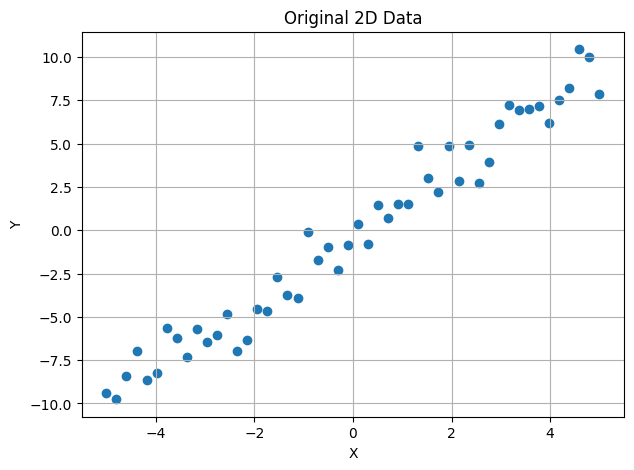

In [3]:
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original 2D Data')
plt.grid(True)
plt.show()

In [4]:
# Centering the points
mean = np.mean(X, axis=0)
X_centered = X - mean

print('Mean:', mean)
print('First 5 centered points:')
print(X_centered[:5])

Mean: [-7.10542736e-17 -2.70568686e-01]
First 5 centered points:
[[-5.         -9.13337433]
 [-4.79591837 -9.48718521]
 [-4.59183673 -8.13587854]
 [-4.3877551  -6.67730569]
 [-4.18367347 -8.3777623 ]]


In [5]:
covariance_matrix = np.cov(X_centered, rowvar=False)

print('Covariance matrix:')
print(covariance_matrix)

Covariance matrix:
[[ 8.85047897 17.08514091]
 [17.08514091 34.1939496 ]]


In [6]:
# EigenValues & EigenVectors
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Sort from largest eigenvalue to smallest
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

print('Eigenvalues:')
print(eigenvalues)
print('\nEigenvectors (columns):')
print(eigenvectors)

PC1 = eigenvectors[:, 0:1]
print('\nPC1:')
print(PC1)

Eigenvalues:
[42.79367205  0.25075651]

Eigenvectors (columns):
[[ 0.44960237 -0.89322881]
 [ 0.89322881  0.44960237]]

PC1:
[[0.44960237]
 [0.89322881]]


In [8]:
variance_explained = eigenvalues / np.sum(eigenvalues)

print('PC1 percentage:', variance_explained[0] * 100, '%')
print('PC2 percentage:', variance_explained[1] * 100, '%')

PC1 percentage: 99.41744722496696 %
PC2 percentage: 0.5825527750330229 %


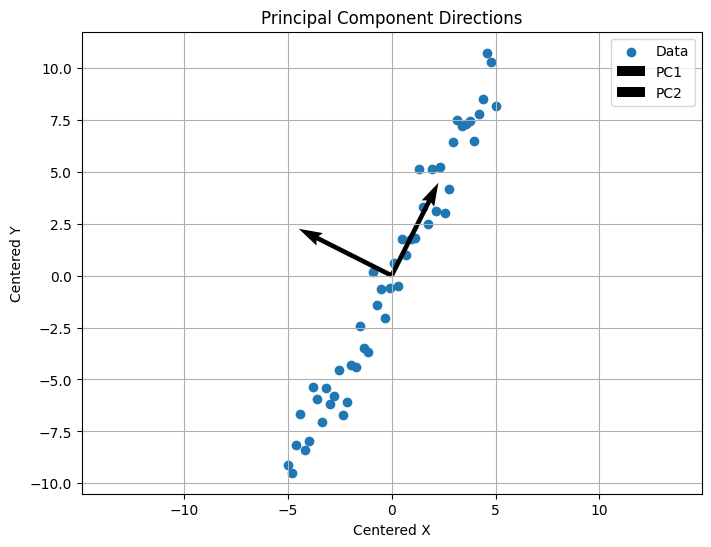

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(X_centered[:,0], X_centered[:,1], label='Data')

scale = 5
pc1 = PC1[:,0] * scale
pc2 = eigenvectors[:,1] * scale

plt.quiver(0, 0, pc1[0], pc1[1], angles='xy', scale_units='xy', scale=1, label='PC1')
plt.quiver(0, 0, pc2[0], pc2[1], angles='xy', scale_units='xy', scale=1, label='PC2')
plt.xlabel('Centered X')
plt.ylabel('Centered Y')
plt.title('Principal Component Directions')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Only Keep PC1
Z = X_centered @ PC1

print('Original shape:', X.shape)
print('Reduced shape:', Z.shape)
print('\nFirst 10 values in the new 1D dimension:')
print(Z[:10])

Original shape: (50, 2)
Reduced shape: (50, 1)

First 10 values in the new 1D dimension:
[[-10.40620494]
 [-10.63048343]
 [ -9.33170179]
 [ -7.93710692]
 [ -9.36424817]
 [ -8.9078918 ]
 [ -6.50786951]
 [ -6.92165502]
 [ -7.79112768]
 [ -6.25001493]]


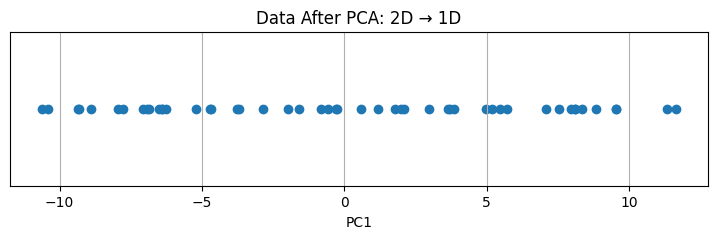

In [11]:
plt.figure(figsize=(9,2))
plt.scatter(Z[:,0], np.zeros(len(Z)))
plt.xlabel('PC1')
plt.yticks([])
plt.title('Data After PCA: 2D → 1D')
plt.grid(True)
plt.show()

In [12]:
# Reconstructing original using PC1
X_reconstructed = Z @ PC1.T + mean

print('Reconstructed shape:', X_reconstructed.shape)
print('\nFirst 5 original points:')
print(X[:5])
print('\nFirst 5 reconstructed points:')
print(X_reconstructed[:5])

Reconstructed shape: (50, 2)

First 5 original points:
[[-5.         -9.40394302]
 [-4.79591837 -9.7577539 ]
 [-4.59183673 -8.40644722]
 [-4.3877551  -6.94787438]
 [-4.18367347 -8.64833099]]

First 5 reconstructed points:
[[-4.67865442 -9.56569075]
 [-4.77949055 -9.76602276]
 [-4.19555525 -8.60591358]
 [-3.56854209 -7.36022126]
 [-4.21018818 -8.63498494]]


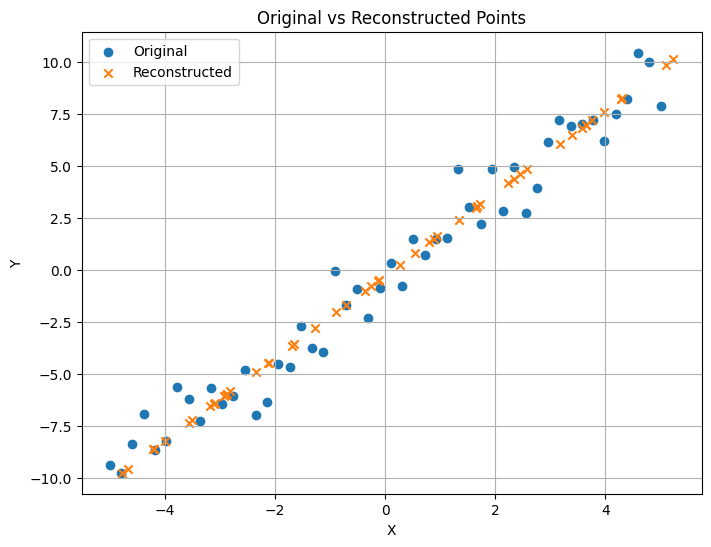

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], label='Original')
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1], marker='x', label='Reconstructed')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original vs Reconstructed Points')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
# Reconstruction Error
squared_error = (X - X_reconstructed) ** 2
mse = np.mean(squared_error)

print('Mean Squared Reconstruction Error:', mse)

Mean Squared Reconstruction Error: 0.12287069142462136
